In [1]:
%load_ext autoreload
%autoreload 2
import pathlib

import numpy as np
import toml
import matplotlib.pyplot as plt
import pandas as pd

from observables_plots import (
    generate_scatter_plot
)
from compute_observables import (
        compute_average_magnetisation,
        compute_average_energy,
        compute_susceptibility,
        compute_specific_heat,
        compute_binder_cumulant,
    )

# Matplotlib plot parameters
plt.rcParams['text.usetex'] = True
plt.rcParams.update({'font.size':14, 'figure.autolayout':True})



project_name = "temperature30_0-3_1-5_l100_dim2_long"
project_path = pathlib.Path("/home/alvaro/Documents/trinity/year4/capstone/capstone-code/projects") / project_name 

In [5]:
params = [x for x in project_path.iterdir() if x.is_dir()]
temperature_array = np.array([])
magnetisation_array = np.array([])
for direc in params:
    config = toml.load(direc / "config.toml")
    temperature_array = np.append(temperature_array, config["physical_settings"]["temperature"])
    magnetisation_array = np.append(magnetisation_array, compute_average_magnetisation(direc))

len(magnetisation_array), len(temperature_array)


(30, 30)

In [58]:
"#" + "="*20

'#===================='

NameError: name 'ticker' is not defined

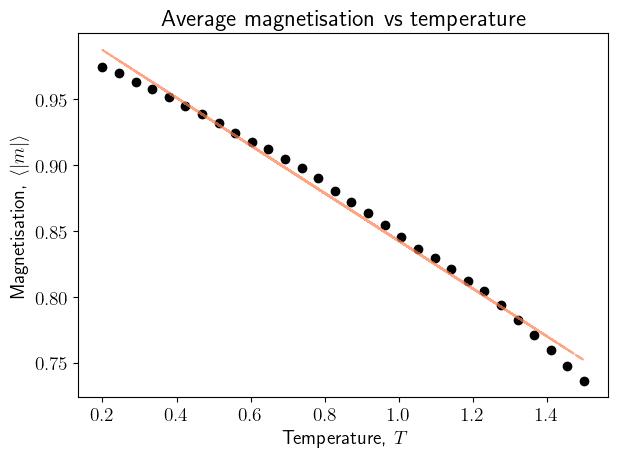

In [51]:
import matplotlib.ticker as ticker
fig, ax = plt.subplots(
    ncols=1,
    nrows=1
)
ax = generate_scatter_plot(
        axs = ax,
        xaxis = temperature_array,
        xlabel="Temperature, $T$",
        yaxis = magnetisation_array,
        ylabel=r"Magnetisation, $\langle |m| \rangle$",
        title = "Average magnetisation vs temperature",
        data_label = "data",
        logscale = False,
        linear_fit = True,
        log_fit = False,
    )

ax.set_ylim([0.7,1])
ax.grid(True, which="both", ls="--", lw=0.5)

# Define a function that wraps the number in LaTeX math symbols
# '$0.7$' instead of just '0.7'
latex_formatter = ticker.FuncFormatter(lambda x, pos: f'${x:g}$')

# Apply it to both axes
ax.xaxis.set_major_formatter(latex_formatter)
ax.yaxis.set_major_formatter(latex_formatter)

# If you have minor ticks you want labeled as well:
ax.yaxis.set_minor_formatter(latex_formatter)
ax.xaxis.set_minor_formatter(latex_formatter)

# ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
# ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
# ax.yaxis.set_minor_formatter(ticker.FormatStrFormatter('$%.1g$'))
# ax.xaxis.set_minor_formatter(ticker.FormatStrFormatter('$%.1g$'))

# ax.tick_params(axis='both', which='major', direction='in', length=6, width=1)
plt.plot()

In [11]:
p_fitted = np.polynomial.Polynomial.fit(temperature_array, magnetisation_array, deg=1)
p_fitted.convert()

Polynomial([ 1.02310308, -0.18075335], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

In [63]:
temp_array = np.linspace(0.3,1.5, 30).tolist()
temp_array

[0.3,
 0.3413793103448276,
 0.38275862068965516,
 0.4241379310344827,
 0.46551724137931033,
 0.506896551724138,
 0.5482758620689655,
 0.5896551724137931,
 0.6310344827586207,
 0.6724137931034482,
 0.7137931034482758,
 0.7551724137931035,
 0.796551724137931,
 0.8379310344827586,
 0.8793103448275863,
 0.9206896551724137,
 0.9620689655172414,
 1.0034482758620689,
 1.0448275862068965,
 1.0862068965517242,
 1.1275862068965516,
 1.1689655172413793,
 1.210344827586207,
 1.2517241379310344,
 1.293103448275862,
 1.3344827586206898,
 1.3758620689655172,
 1.4172413793103449,
 1.4586206896551726,
 1.5]

In [ ]:
import json
data = {
    "git_hash": "v0.0-1-g3b72578-dirty",
    "seed": 42,
    "physical_settings": {
        "temperature": np.linspace(0.3,1.5, 30).tolist(),
        "L": 100,
        "dimension": 2,
        "J": 1,
        "potts_q": 3,
        "H": 1.0,
        "vec_H": [0.0, 1.0, 2.0]
    },
    "simulation_settings": {
        "time_steps": 10000000,
        "recording_steps": 10000,
        "record_magnetisation": True,
        "record_energy": True,
        "record_susceptibility": True,
        "record_specific_heat": True,
        "record_correlation_length": False,
        "record_correlation_function": False
    }
}
path = "/home/alvaro/Documents/trinity/year4/capstone/capstone-code/projects/temperature30_0-3_1-5_l100_dim2_long/global_parameters.json"
with open("global_parameters.json", "w") as f:
    json.dump(data, f)